# ==========================================
# 🏏 Ball-by-Ball Exploratory Data Analysis
# ==========================================


1. Batting Analysis
   • Top Run Scorers
   • Most Fours
   • Most Sixes
   • Strike Rate
   • Balls Faced
   • Dot Balls
   • Boundary Percentage

2. Bowling Analysis
   • Most Balls Bowled
   • Runs Conceded
   • Economy Rate
   • Top Wicket Takers (if wicket data exists)

3. Match Flow Analysis
   • Powerplay vs Middle Overs vs Death Overs
   • Total Runs Distribution

In [89]:
import warnings

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import psycopg2
import scipy.stats as stats
from scipy.stats import ttest_ind
from sqlalchemy import URL, create_engine

warnings.filterwarnings("ignore")

In [90]:
DB_CONFIG = {
    "host": "localhost",
    "database": "ipldatabase",
    "user": "postgres",
    "password": "vk@123456#",
    "port": 5432,
}

db_url = URL.create(
    "postgresql+psycopg2",
    username=DB_CONFIG["user"],
    password=DB_CONFIG["password"],
    host=DB_CONFIG["host"],
    port=DB_CONFIG["port"],
    database=DB_CONFIG["database"],
)

engine = create_engine(db_url)
conn = psycopg2.connect(**DB_CONFIG)

final_table = pd.read_sql_query("SELECT * FROM final_table", engine)

print("Database connected successfully.")
print("final_table loaded:", final_table.shape)

Database connected successfully.
final_table loaded: (244837, 29)


In [91]:
top_scorers = (final_table.groupby('batter')['batsman_runs'].sum())
print(top_scorers.head(10).to_string())

batter
A Ashish Reddy    280
A Badoni          575
A Chandila          4
A Chopra           53
A Choudhary        25
A Dananjaya         4
A Flintoff         62
A Kamboj            2
A Kumble           35
A Manohar         231


In [92]:
top_scorers = (
    final_table
    .groupby('batter')['batsman_runs']
    .sum()
    .sort_values(ascending=False)
)

print(top_scorers.head(10))

batter
V Kohli           7516
RG Sharma         6476
S Dhawan          6341
DA Warner         6000
SK Raina          5448
MS Dhoni          5027
CH Gayle          4738
RV Uthappa        4714
AB de Villiers    4645
KD Karthik        4645
Name: batsman_runs, dtype: int64


In [93]:
matches = (
    final_table
    .groupby('batter')['match_id']
    .nunique()
    .sort_values(ascending=False)
    .reset_index(name='matches_played')
)
print(matches)

             batter  matches_played
0         RG Sharma             241
1           V Kohli             225
2        KD Karthik             221
3          MS Dhoni             214
4          S Dhawan             204
..              ...             ...
663  Vivrant Sharma               1
664         A Tomar               1
665      Yash Dayal               1
666     Younis Khan               1
667        A Kamboj               1

[668 rows x 2 columns]


In [94]:
merged = pd.merge(
    top_scorers,
    matches,
    on='batter'
)

merged = merged.sort_values(
    by='batsman_runs',
    ascending=False
)

print(merged.head(10))

           batter  batsman_runs  matches_played
0         V Kohli          7516             225
1       RG Sharma          6476             241
2        S Dhawan          6341             204
3       DA Warner          6000             166
4        SK Raina          5448             195
5        MS Dhoni          5027             214
6        CH Gayle          4738             132
7      RV Uthappa          4714             186
8  AB de Villiers          4645             154
9      KD Karthik          4645             221


In [95]:
most_fours = (
    final_table[final_table['batsman_runs'] == 4]
    .groupby('batter')
    .size()
    .sort_values(ascending=False)
)
print(most_fours.head(10))

batter
S Dhawan        717
V Kohli         680
DA Warner       616
RG Sharma       589
SK Raina        499
G Gambhir       492
AM Rahane       470
RV Uthappa      457
KD Karthik      447
F du Plessis    394
dtype: int64


In [96]:
most_six = (
    final_table[final_table['batsman_runs']== 6 ]
    .groupby('batter')
    .size()
    .sort_values(ascending=False)

)
print(most_six.head(10))

batter
CH Gayle          335
RG Sharma         273
V Kohli           259
MS Dhoni          243
AB de Villiers    226
DA Warner         216
AD Russell        201
KA Pollard        200
SK Raina          200
SV Samson         177
dtype: int64


In [97]:
ball_faced = (
    final_table.groupby('batter')['ball'].sum().sort_values(ascending=False)
)
print(ball_faced.head(10))

batter
V Kohli       20198
S Dhawan      18309
RG Sharma     17879
DA Warner     15488
SK Raina      14942
MS Dhoni      14003
RV Uthappa    13275
AM Rahane     13077
KD Karthik    12963
G Gambhir     12564
Name: ball, dtype: int64


In [98]:
dot_ball = (
    final_table[final_table['batsman_runs']== 0]
    .groupby('batter')
    .size()
    .sort_values(ascending=False)
)
    
print(dot_ball.head(10))

batter
V Kohli       2071
S Dhawan      2035
RG Sharma     1976
DA Warner     1701
CH Gayle      1554
RV Uthappa    1533
SK Raina      1441
AM Rahane     1421
MS Dhoni      1347
G Gambhir     1347
dtype: int64


In [99]:
boundary_hitting_per = (
    (most_fours+most_six)/ball_faced * 100).sort_values(ascending = False) 
print(boundary_hitting_per.head(10))

batter
J Fraser-McGurk    10.810811
PD Salt             8.000000
Umar Gul            7.792208
LJ Wright           7.755102
AC Blizzard         7.443366
SP Narine           7.386036
Kamran Akmal        7.216495
MJ Lumb             7.142857
Shahid Afridi       7.142857
YBK Jaiswal         7.043786
dtype: float64


bowling analysis 

In [100]:
extra_run_by_bowler = (
    final_table.groupby('bowler')['extra_runs']
    .sum()
    .sort_values(ascending=False)
    .reset_index()
)
print(extra_run_by_bowler.head(10))

           bowler  extra_runs
0         B Kumar         299
1      SL Malinga         277
2        DJ Bravo         249
3        R Ashwin         247
4        UT Yadav         245
5         P Kumar         236
6        I Sharma         233
7  Mohammed Siraj         215
8       JJ Bumrah         210
9        HV Patel         200


In [101]:
most_ball_drop_by_bowler = (
    final_table.groupby('bowler')
    .size()
    .sort_values(ascending=False)
    .reset_index(name='balls')
)
print(most_ball_drop_by_bowler.head(10))

            bowler  balls
0         R Ashwin   4331
1        SP Narine   3989
2          B Kumar   3916
3        PP Chawla   3769
4        RA Jadeja   3398
5  Harbhajan Singh   3375
6         A Mishra   3287
7        YS Chahal   3283
8         DJ Bravo   3161
9         UT Yadav   3086


In [102]:
runs_conceded = (
    final_table.groupby('bowler')['total_runs']
    .sum()
    .sort_values(ascending=False)
    .reset_index(name='runsgiven')
)
print(runs_conceded.head(10))

            bowler  runsgiven
0         R Ashwin       5061
1        PP Chawla       4984
2          B Kumar       4904
3        SP Narine       4478
4        YS Chahal       4286
5        RA Jadeja       4281
6         DJ Bravo       4257
7         UT Yadav       4254
8  Harbhajan Singh       3985
9         A Mishra       3967


In [103]:
economy_df = pd.merge(
    runs_conceded,
    most_ball_drop_by_bowler,
    on='bowler'
)
economy_df = economy_df[
    economy_df['balls']> 1000
    ]

economy_df['economy_rate'] = (
    economy_df['runsgiven']
    / economy_df['balls']
) * 6

# Round values
economy_df['economy_rate'] = economy_df['economy_rate'].round(2)

# Best economy bowlers
economy_df = economy_df.sort_values(
    'economy_rate',
    ascending=True
)

print(economy_df.head(10).to_string(index=False))



         bowler  runsgiven  balls  economy_rate
 M Muralitharan       1595   1452          6.59
      SP Narine       4478   3989          6.74
       DW Steyn       2375   2113          6.74
       R Ashwin       5061   4331          7.01
     SL Malinga       3340   2851          7.03
    Rashid Khan       3104   2634          7.07
Harbhajan Singh       3985   3375          7.08
       M Kartik       1337   1131          7.09
       A Mishra       3967   3287          7.24
       SK Warne       1449   1199          7.25


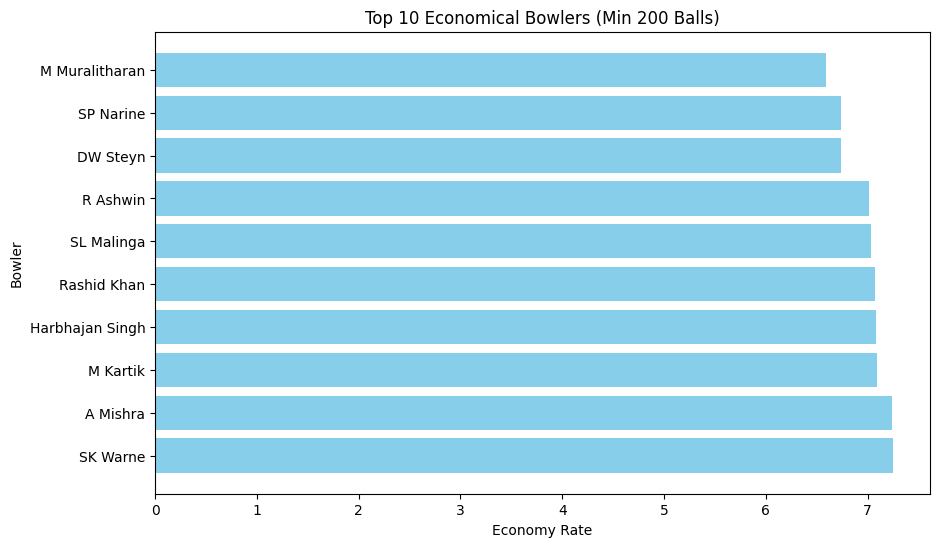

In [104]:
top10_economy = (
    economy_df
    .sort_values('economy_rate')
    .head(10)
)

plt.figure(figsize=(10,6))

plt.barh(
    top10_economy['bowler'],
    top10_economy['economy_rate'],
    color='skyblue'
)

plt.xlabel("Economy Rate")
plt.ylabel("Bowler")
plt.title("Top 10 Economical Bowlers (Min 200 Balls)")

plt.gca().invert_yaxis()

plt.show()

match_flow_analysis

starting overs , middle overs and death overs 
runs scored in all three phase 

In [105]:
def phase(over):

    if over <= 6:
        return 'Powerplay'

    elif over <= 15:
        return 'Middle Overs'

    else:
        return 'Death Overs'

In [106]:
final_table['phase'] = final_table['over'].apply(phase)

In [107]:
phase_runs = (
    final_table
    .groupby('phase')['total_runs']
    .sum()
    .reset_index()
)

print(phase_runs)

          phase  total_runs
0   Death Overs       70736
1  Middle Overs      145176
2     Powerplay      110899


In [109]:
innings_runs = (
    final_table
    .groupby(['match_id', 'inning'])['total_runs']
    .sum()
    .reset_index(name='innings_score')
)

print(innings_runs.head(10))

  match_id  inning  innings_score
0  1082591       1            207
1  1082591       2            172
2  1082592       1            184
3  1082592       2            187
4  1082593       1            183
5  1082593       2            184
6  1082594       1            163
7  1082594       2            164
8  1082595       1            157
9  1082595       2            142


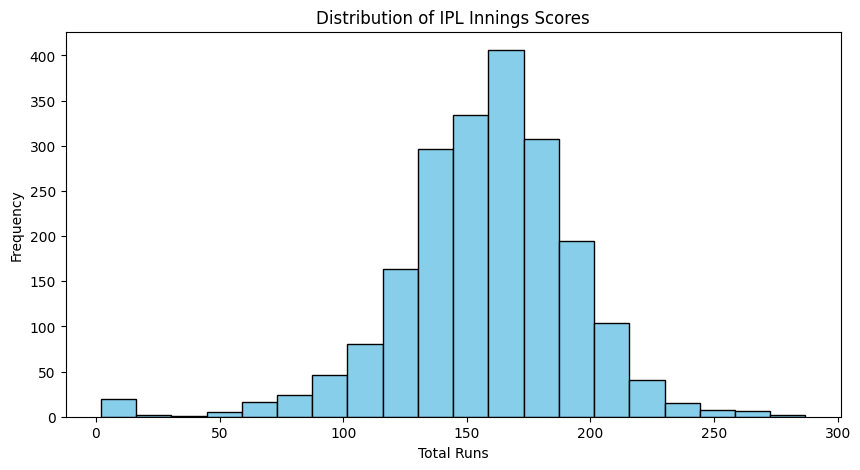

In [110]:
import matplotlib.pyplot as plt

plt.figure(figsize=(10,5))

plt.hist(
    innings_runs['innings_score'],
    bins=20,
    color='skyblue',
    edgecolor='black'
)

plt.title('Distribution of IPL Innings Scores')
plt.xlabel('Total Runs')
plt.ylabel('Frequency')

plt.show()